In [3]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

In [5]:

df = pd.read_csv('Churn_Modelling.csv')

In [6]:

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Гипотеза №1 <br>
Нулевая гипотеза (H0): Срок сотрудничества не вступает в зависимость с оттоком<br>

Альтернативная гипотеза (H1): Клиенты с небольшим сроком сотрудничества (Tenure < 2 лет) могут чаще уходить<br>

Предпосылки: у клиентов, кто недавно пользуется услугами еще не сформировалась лояльность к банку.<br>

Способ проверки гипотезы: хи-квадрат тест на независимость<br>

Уровень значимости: 0.05

In [8]:

# Создание бинарной переменной для Tenure
df['Tenure_Group'] = np.where(df['Tenure'] < 2, 'Less than 2', '2 or more')

In [10]:
# Таблица сопряженности
contingency_table = pd.crosstab(df['Tenure_Group'], df['Exited'])
print("Таблица сопряженности:")
print(contingency_table)

Таблица сопряженности:
Exited           0     1
Tenure_Group            
2 or more     6842  1710
Less than 2   1121   327


In [11]:
# Хи-квадрат тест
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"\nРезультаты хи-квадрат теста: p-value = {p_value:.4f}")


Результаты хи-квадрат теста: p-value = 0.0260


In [13]:
# Доли оттока
p_less_than_2 = count[0] / nobs[0]
p_2_or_more = count[1] / nobs[1]
print(f"\nДоля оттока (Tenure < 2): {p_less_than_2:.4f}")
print(f"Доля оттока (Tenure >= 2): {p_2_or_more:.4f}")


Доля оттока (Tenure < 2): 0.2258
Доля оттока (Tenure >= 2): 0.2000


Выводы:<br>

1. Статистическая значимость различий<br>
p-value = 0.026 (< 0.05) → Разница в оттоке статистически значима.<br>

Это означает, что мы отвергаем нулевую гипотезу (о том, что срок сотрудничества не влияет на отток) и принимаем альтернативную: клиенты с небольшим сроком сотрудничества (Tenure < 2 лет) уходят достоверно чаще, чем клиенты с более длительным сроком.<br>

2. Размер эффекта<br>
Доля оттока в группе Tenure < 2 лет: 22.58%<br>

Доля оттока в группе Tenure ≥ 2 лет: 20.00%<br>

Абсолютная разница: 2.58 процентных пункта<br>

3.Возможные причины:<br>

Недостаточная адаптация (клиенты не успели "привыкнуть" к сервису).<br>

Ошибки в onboarding-процессе (например, сложный интерфейс, отсутствие персональной поддержки).<br>

Маркетинговые ожидания не совпали с реальностью (например, клиентов привлекли агрессивными акциями, но сервис их разочаровал).<br>

In [ ]:
Гипотеза №1 <br>
Нулевая гипотеза (H0): Баланс не вступает в зависимость с оттоком<br>

Альтернативная гипотеза (H1):Клиенты с высоким балансом уходят чаще<br>

Предпосылки:клиенты могут себя вести по разному в зависимости от баланса<br>

Способ проверки гипотезы: Двухвыборочный t-тест (независимый t-тест) и U-теста Манна-Уитни <br>

Уровень значимости: 0.05

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [26]:
# Загрузка данных
data = pd.read_csv('Churn_Modelling.csv')

In [32]:
# Разделение данных на две группы: ушедшие и оставшиеся клиенты
exited_balance = data[data['Exited'] == 1]['Balance']
not_exited_balance = data[data['Exited'] == 0]['Balance']

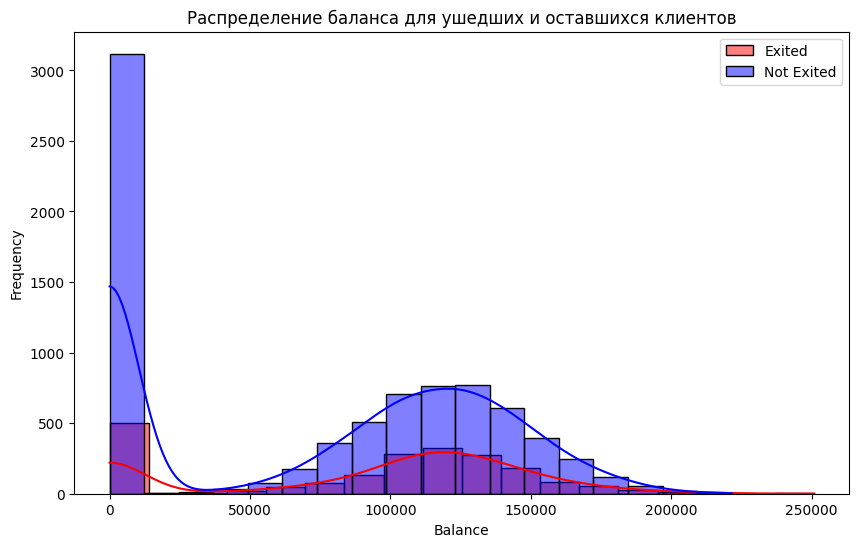

In [33]:
# Визуализация распределения баланса
plt.figure(figsize=(10, 6))
sns.histplot(exited_balance, color='red', label='Exited', kde=True)
sns.histplot(not_exited_balance, color='blue', label='Not Exited', kde=True)
plt.title('Распределение баланса для ушедших и оставшихся клиентов')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [35]:
# Двухвыборочный t-тест (предполагаем, что дисперсии не равны)
t_stat, p_value = stats.ttest_ind(exited_balance, not_exited_balance, equal_var=False)
print("\nРезультаты двухвыборочного t-теста:")
print("t-статистика:", t_stat)
print("p-value:", p_value)


Результаты двухвыборочного t-теста:
t-статистика: 12.471280320050688
p-value: 6.318663518527974e-35


In [36]:
# U-тест Манна-Уитни (непараметрический аналог)
u_stat, p_value_mann = stats.mannwhitneyu(exited_balance, not_exited_balance)
print("\nРезультаты U-теста Манна-Уитни:")
print("U-статистика:", u_stat)
print("p-value:", p_value_mann)


Результаты U-теста Манна-Уитни:
U-статистика: 9371186.5
p-value: 1.1158399379149222e-28


Вывод: <br>
Исходя из результатов двухвыборочного t-теста и U-теста Манна-Уитни, мы отвергаем нулевую гипотезу о том, что баланс не влияет на отток клиентов. Это решение основано на очень низких значениях p-value (6.32e-35 и 1.11e-28), которые значительно меньше стандартного уровня значимости 0.05. Эти результаты указывают на наличие статистически значимой зависимости: клиенты с высоким балансом действительно имеют более высокий риск ухода.